In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df_short = pd.read_csv("Overlapping_peaks_across_conditions_avg_annotated_hg19gtf_stats_short.tsv", sep = "\t")
df_long = pd.read_csv("Overlapping_peaks_across_conditions_avg_annotated_hg19gtf_stats_long.tsv", sep = "\t")

In [19]:
df_short['LogP enrichment (+values depleted)'] = -df_short['LogP enrichment (+values depleted)']
df_long['LogP enrichment (+values depleted)'] = -df_long['LogP enrichment (+values depleted)']

In [20]:
df_short

,Annotation,Number of peaks,Total size (bp),Log2 Ratio (obs/exp),LogP enrichment (+values depleted)
0,TTS,587,165635111,-0.308,-17.659
1,Exon,379,98247198,-0.186,-5.278
2,Intron,4212,1698567606,-0.823,-1571.852
3,Intergenic,1945,985770503,-1.153,-1111.120
4,Promoter,6521,161244710,3.204,10237.685


In [51]:
df_long = df_long.sort_values(by='LogP enrichment (+values depleted)', ascending=False)
df_long

,Annotation,Number of peaks,Total size (bp),Log2 Ratio (obs/exp),LogP enrichment (+values depleted)
23,protein_coding-promoter,4854,76302027,3.914,9518.947
8,lncRNA-promoter,1415,58377928,2.522,1361.755
69,rRNA-promoter,16,52261,6.181,55.074
10,transcribed_unprocessed_pseudogene-promoter,37,1392557,2.654,39.548
130,snRNA-promoter,39,2073392,2.156,30.577
...,...,...,...,...,...
123,protein_coding-TTS,237,75250350,-0.422,-13.778
127,protein_coding-exon,138,59515443,-0.864,-33.598
65,lncRNA-intron,1466,712940376,-1.037,-599.449
33,protein_coding-intron,2730,1091469295,-0.755,-634.652


In [ ]:
df_long

In [ ]:
df = df_short

In [202]:
def Dual_axis_plot(df, x_axis, y1, y2, 
                   xlabel, ylabel1, ylabel2, 
                   Ylim_axis2 = None,
                   FigSize = (6,4), Save = None):
    # ---------- Styling ----------
    sns.set_theme(style="white", context="talk")
    plt.rcParams.update({
        'font.family': 'Arial',
        'axes.linewidth': 1.2,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'figure.dpi': 300
    })
    
    # ---------- Plot Setup ----------
    fig, ax1 = plt.subplots(figsize=FigSize)
    
    # X-axis positions
    x = range(len(df))
    width = 0.35  # width of the bars
    
    # Primary axis (left)
    bars1 = ax1.bar(
        [p - width/2 for p in x],
        df[y1],
        width=width,
        color='#4C72B0'
    )
    ax1.set_ylabel(ylabel1, color='#4C72B0')
    ax1.tick_params(axis='y', colors='#4C72B0')
    
    # Secondary axis (right)
    ax2 = ax1.twinx()
    bars2 = ax2.bar(
        [p + width/2 for p in x],
        df[y2],
        width=width,
        color='#55A868'
    )
    ax2.set_ylabel(ylabel2, color='#55A868')
    ax2.tick_params(axis='y', colors='#55A868')

    if Ylim_axis2 != None:
        ax2.set_ylim(Ylim_axis2[0], Ylim_axis2[1])
    
    # Change the ylim for left axis so left and right axes align at 0
    left_ymin, left_ymax = ax1.get_ylim()
    right_ymin, right_ymax = ax2.get_ylim()

    if right_ymax == 0:
        right_ymax = -right_ymin
        ax2.set_ylim(right_ymin, right_ymax)
    elif right_ymin == 0:
        right_ymin = -right_ymin
        ax2.set_ylim(right_ymin, right_ymax)

    range_above_0 = right_ymax - 0
    range_below_0 = 0 - right_ymin
    below_0_ratio = range_below_0/range_above_0

    left_adaptation = -(below_0_ratio * left_ymax)
    ax1.set_ylim(left_adaptation, left_ymax)
    
    plt.axhline(0, color='black', linewidth=1.2)

    
    
    
    # ---------- X-axis labels ----------
    ax1.set_xticks(x)
    ax1.set_xticklabels(df[x_axis], rotation=90)
    ax1.set_xlabel(xlabel)
    
    # ---------- Legend ----------
    # Combine legends from both axes
    bars = bars1 + bars2
    labels = [b.get_label() for b in bars]
    ax1.legend(bars, labels, frameon=False, loc='upper left')
    
    # ---------- Aesthetics ----------
    sns.despine(ax=ax1, right=False)
    #ax1.set_title('Gene Expression vs Protein Level', pad=15, weight='bold')
    
    plt.tight_layout()
    if Save != None:
        plt.savefig(Save, dpi=600, bbox_inches='tight')
    plt.show()

C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\3913583878.py:82: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9D8E7D280> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\3913583878.py:82: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9D8E7DAF0> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\3913583878.py:82: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9D8E7D2B0> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\3913583878.py:82: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x0000

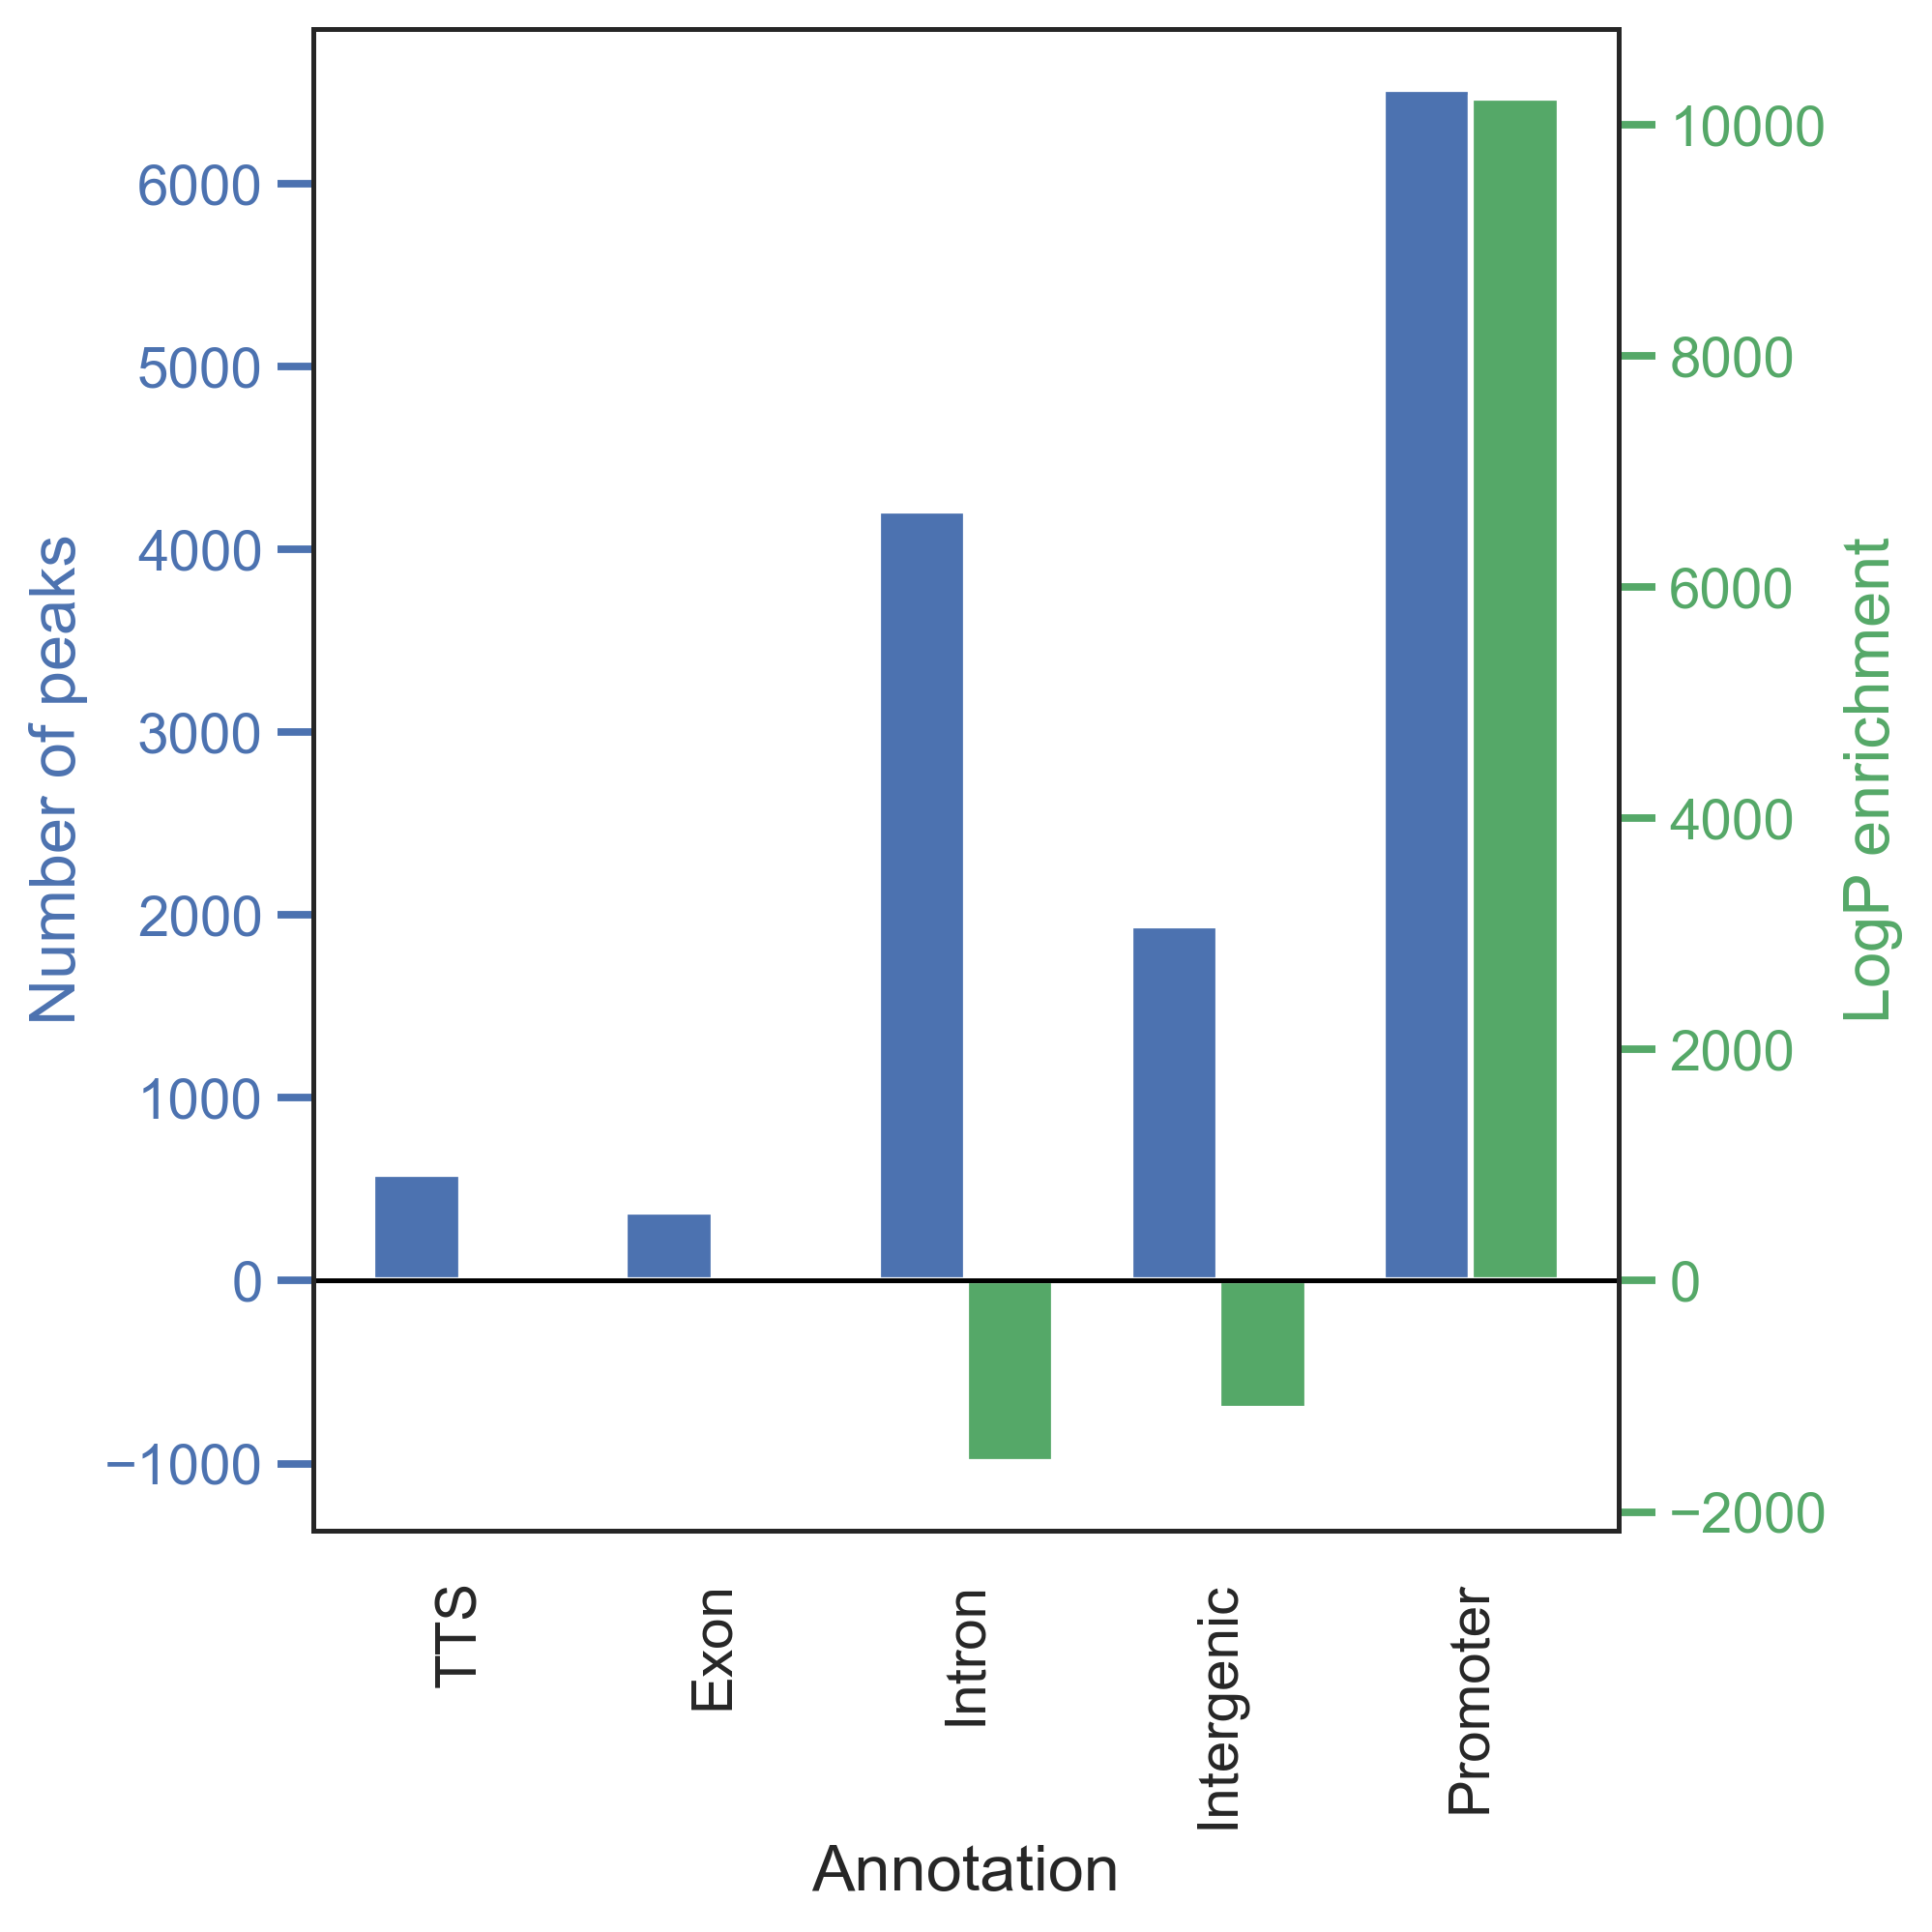

In [80]:
Dual_axis_plot(df_short, 
               x_axis = "Annotation", 
               y1 = "Number of peaks", 
               y2 = "LogP enrichment (+values depleted)", 
               xlabel = "Annotation",
               ylabel1 = "Number of peaks",
               ylabel2 = "LogP enrichment",
               FigSize = (7,7),
               Save = None)

C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9DC090C10> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9DC0908E0> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9E7496280> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x0000

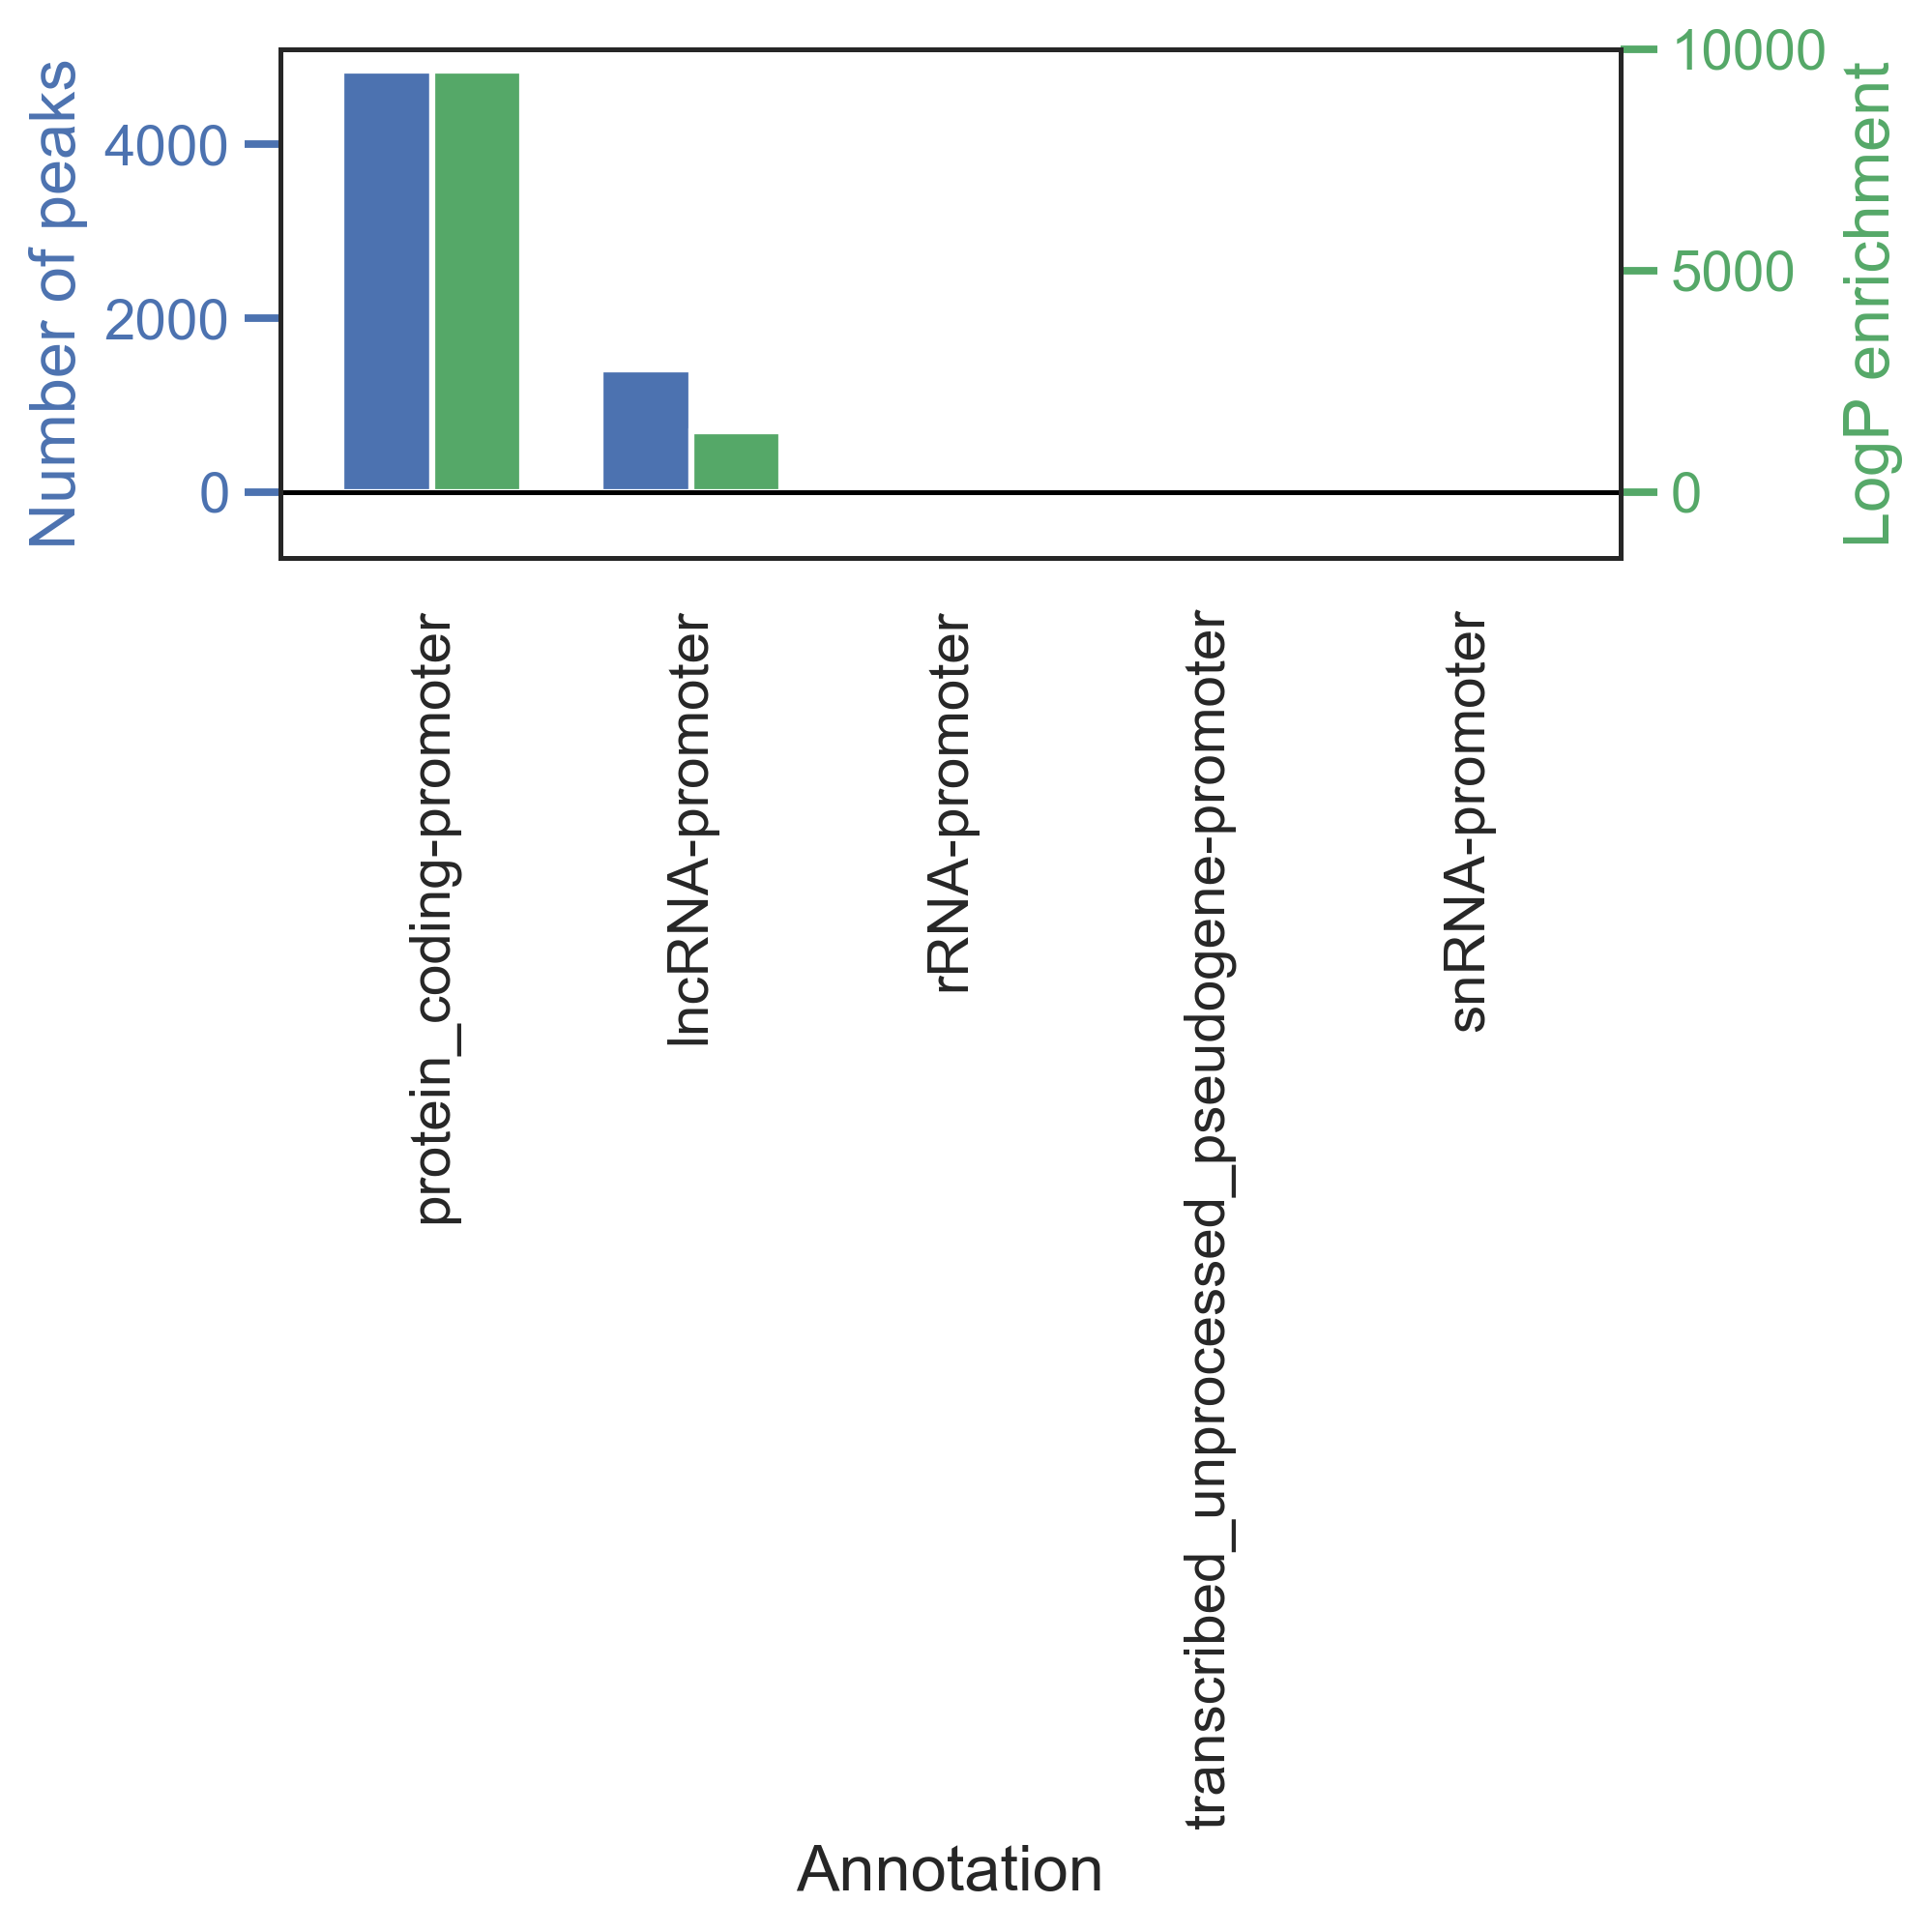

In [203]:
Dual_axis_plot(df_long[0:5], 
               x_axis = "Annotation", 
               y1 = "Number of peaks", 
               y2 = "LogP enrichment (+values depleted)", 
               xlabel = "Annotation",
               ylabel1 = "Number of peaks",
               ylabel2 = "LogP enrichment",
               FigSize = (7,7),
               Ylim_axis2 = (-1500, 10000),
               Save = "figures/Fig7C positively enriched.pdf")

C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9DCA16AF0> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9DCA168E0> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x000001A9DCA16CD0> starts with '_'. It is thus excluded from the legend.
  ax1.legend(bars, labels, frameon=False, loc='upper left')
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\2368463751.py:79: UserWarning: The label '_nolegend_' of <matplotlib.patches.Rectangle object at 0x0000

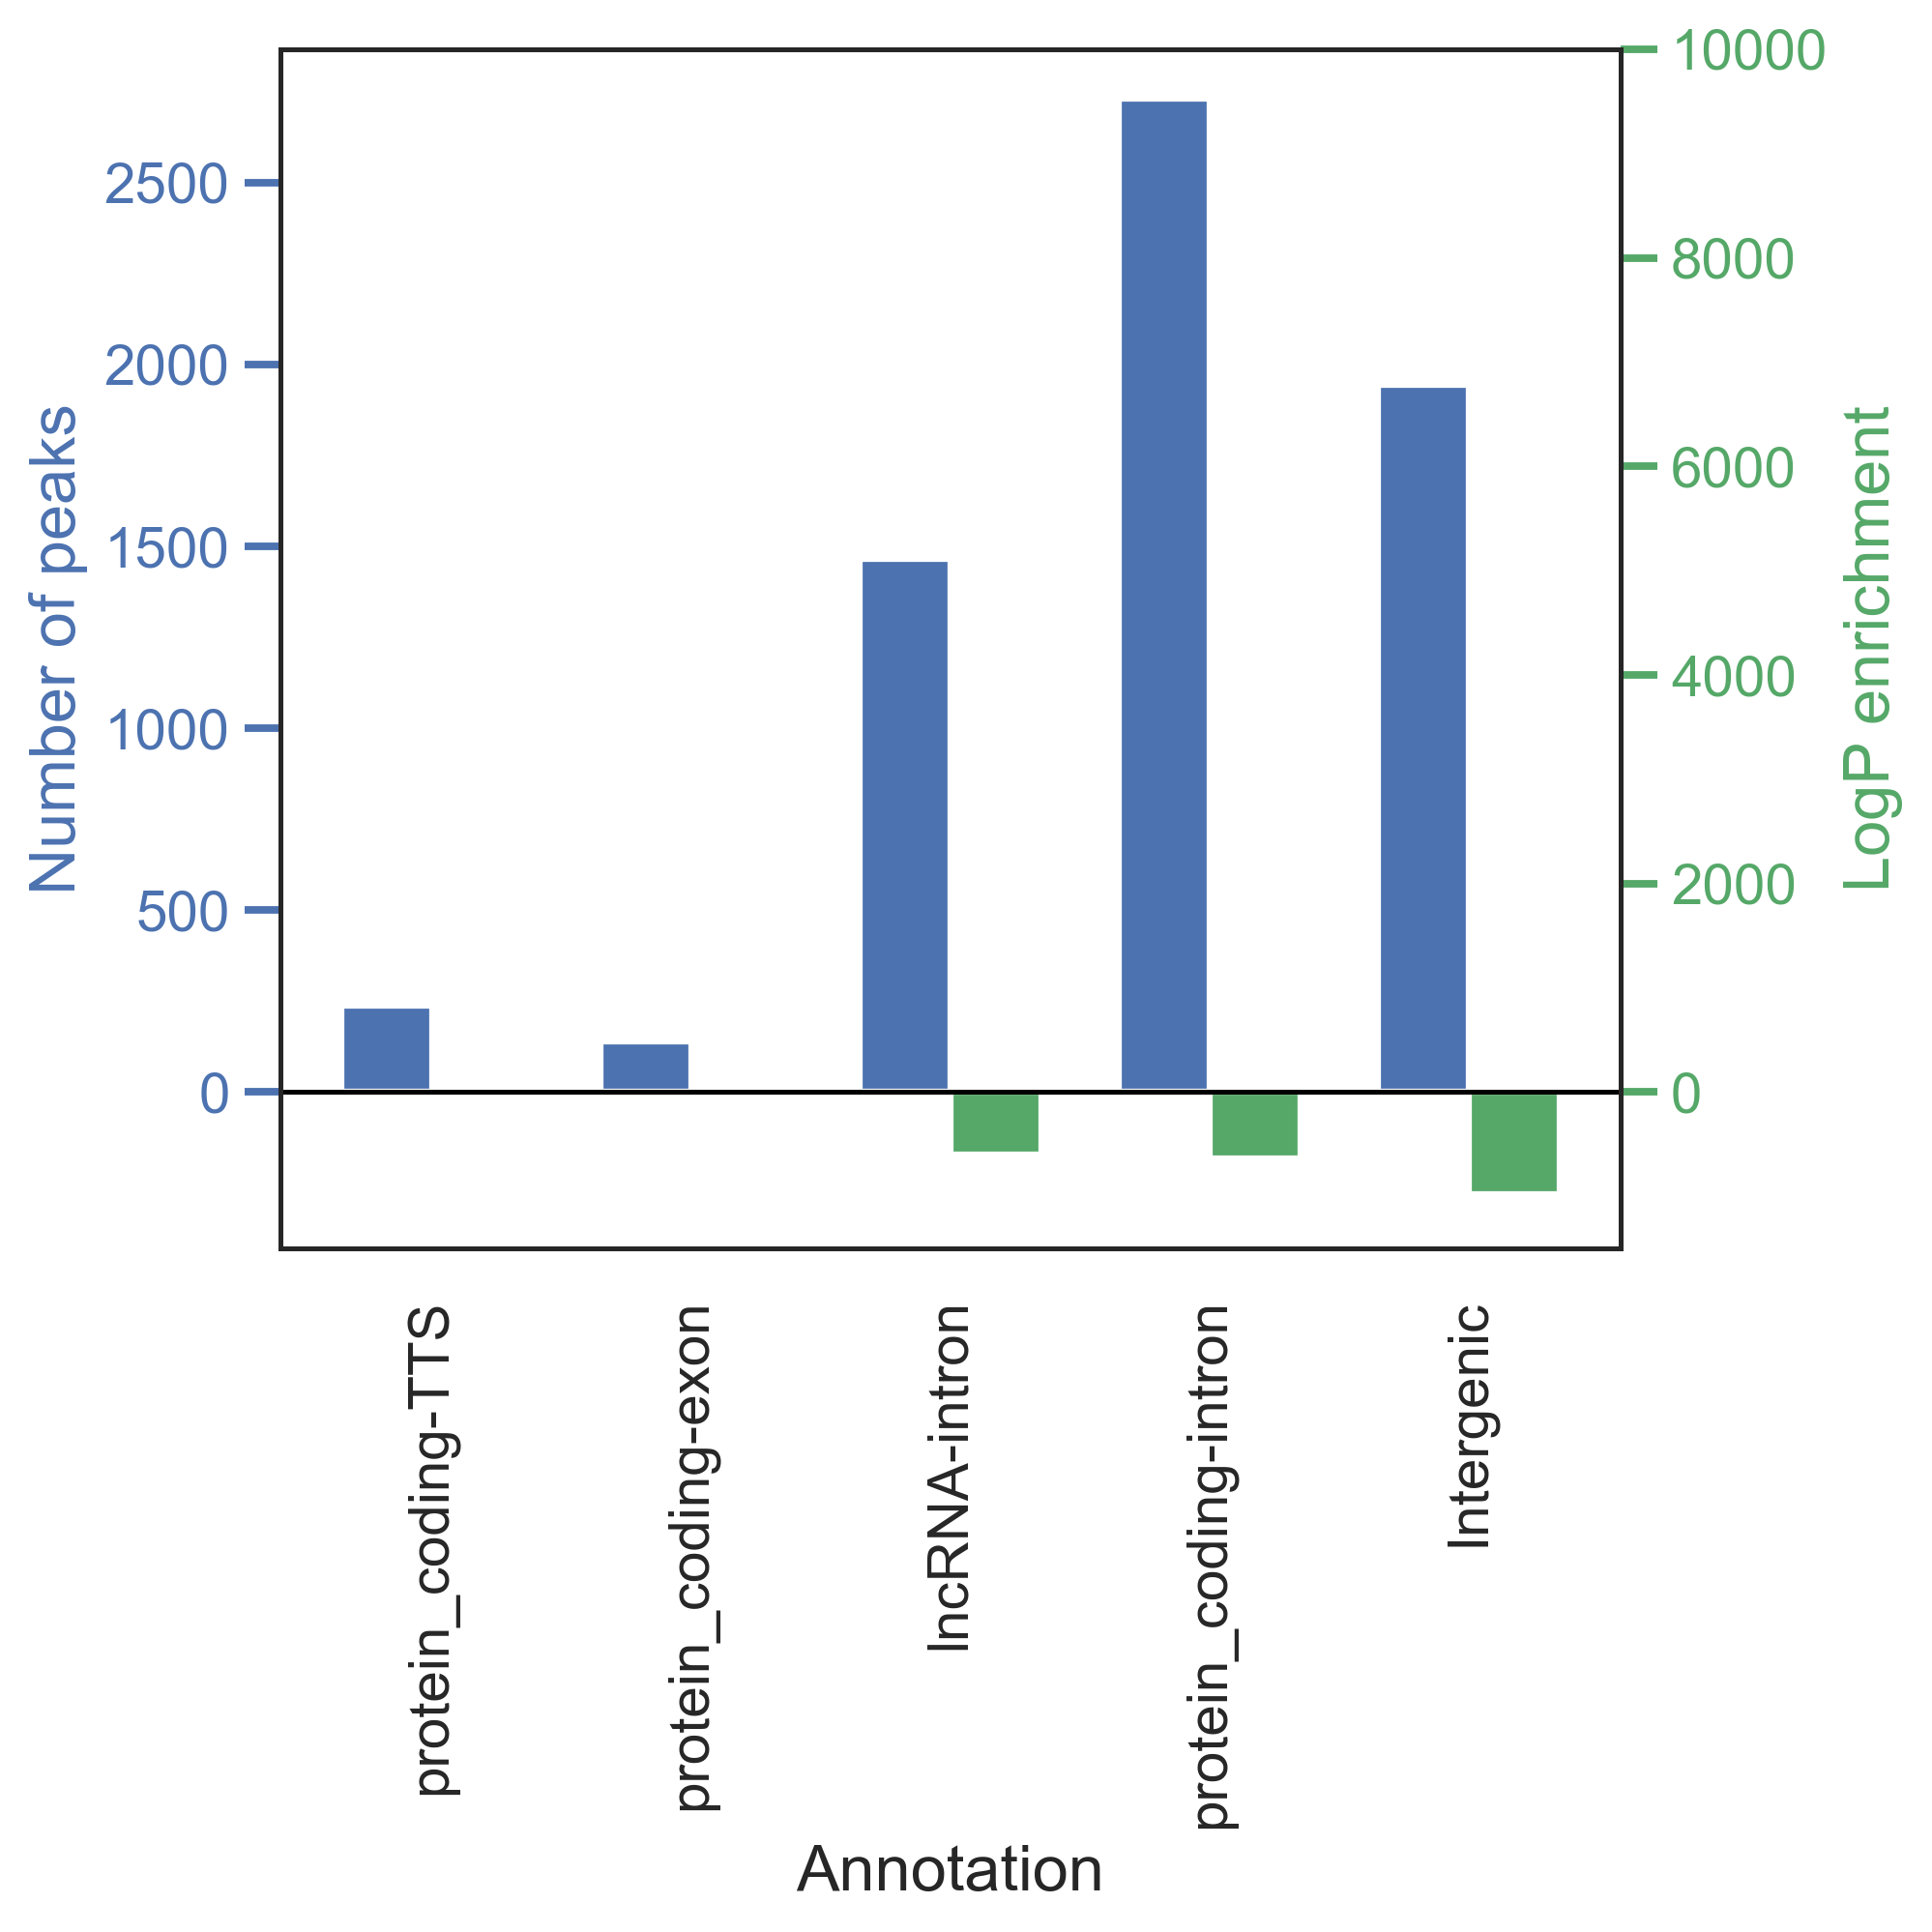

In [204]:
Dual_axis_plot(df_long[-5:], 
               x_axis = "Annotation", 
               y1 = "Number of peaks", 
               y2 = "LogP enrichment (+values depleted)", 
               xlabel = "Annotation",
               ylabel1 = "Number of peaks",
               ylabel2 = "LogP enrichment",
               FigSize = (7,7),
               Ylim_axis2 = (-1500,10000),
               Save = "figures/Fig7C negatively enriched.pdf")

In [54]:
df_long[-10:]

,Annotation,Number of peaks,Total size (bp),Log2 Ratio (obs/exp),LogP enrichment (+values depleted)
73,transcribed_unitary_pseudogene-intron,2,1903070,-2.006,-4.312
114,pseudogene-intron,1,1538941,-2.699,-4.481
16,unprocessed_pseudogene-TTS,1,1739433,-2.876,-5.221
49,processed_pseudogene-exon,6,4122329,-1.536,-6.457
52,unprocessed_pseudogene-intron,4,3361517,-1.826,-6.458
123,protein_coding-TTS,237,75250350,-0.422,-13.778
127,protein_coding-exon,138,59515443,-0.864,-33.598
65,lncRNA-intron,1466,712940376,-1.037,-599.449
33,protein_coding-intron,2730,1091469295,-0.755,-634.652
63,Intergenic,1945,985770503,-1.097,-981.055


In [119]:
df_annotation = pd.read_csv("Overlapping_peaks_across_conditions_avg_annotated.txt", sep = "\t")
df_annotation.columns.values[0] = "PeakID"

In [121]:
df_annotation = df_annotation[df_annotation['Annotation'].str.contains('TSS', case=False, regex=False, na=False)]
df_annotation = df_annotation[df_annotation['Gene Type'].str.contains('protein-coding', case=False, regex=False, na=False)]

In [122]:
df_annotation

,PeakID,Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
46,n47_qval0.01_peak_19377,chr4,71705579,71706048,+,816.25,NaN,promoter-TSS (NM_001098477),promoter-TSS (NM_001098477),-206.0,NM_002092,2926.0,NaN,NM_002092,ENSG00000132463,GRSF1,-,G-rich RNA sequence binding factor 1,protein-coding
54,n47_qval0.01_peak_1445,chr1,143912953,143913908,+,761.50,NaN,promoter-TSS (NM_001346071),promoter-TSS (NM_001346071),-261.0,NM_207418,728833.0,NaN,NM_207418,ENSG00000215784,FAM72D,GCUD2,family with sequence similarity 72 member D,protein-coding
55,n47_qval0.01_peak_15742,chr2,242294790,242295656,+,756.50,NaN,promoter-TSS (NM_014808),promoter-TSS (NM_014808),-477.0,NM_001282984,9855.0,NaN,NM_014808,ENSG00000006607,FARP2,FIR|FRG|PLEKHC3,"FERM, ARH/RhoGEF and pleckstrin domain protein 2",protein-coding
64,n47_qval0.01_peak_4417,chr11,62609619,62609768,+,718.50,NaN,promoter-TSS (NM_001369451),promoter-TSS (NM_001369451),-412.0,NM_001369451,54663.0,NaN,NM_018093,ENSG00000133316,WDR74,Nsa1,WD repeat domain 74,protein-coding
97,n47_qval0.01_peak_2292,chr1,206137692,206138514,+,591.25,NaN,promoter-TSS (NM_001287385).2,promoter-TSS (NM_001287385).2,-337.0,NM_001287385,554282.0,NaN,NM_001287385,ENSG00000263513,FAM72C,-,family with sequence similarity 72 member C,protein-coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13943,n47_qval0.01_peak_23351,chr6,150067631,150067780,+,41.75,NaN,promoter-TSS (NR_104456),promoter-TSS (NR_104456),-40.0,NM_198887,348995.0,NaN,NM_024647,ENSG00000120253,NUP43,bA350J20.1|p42,nucleoporin 43,protein-coding
13947,n47_qval0.01_peak_1857,chr1,160040043,160040418,+,41.25,NaN,promoter-TSS (NM_002241),promoter-TSS (NM_002241),-280.0,NM_002241,3766.0,NaN,NM_002241,ENSG00000177807,KCNJ10,BIRK-10|KCNJ13-PEN|KIR1.2|KIR4.1|SESAME,potassium inwardly rectifying channel subfamil...,protein-coding
13951,n47_qval0.01_peak_13990,chr2,26205635,26205898,+,41.00,NaN,promoter-TSS (NM_002254),promoter-TSS (NM_002254),-400.0,NM_002254,3797.0,NaN,NM_002254,ENSG00000084731,KIF3C,-,kinesin family member 3C,protein-coding
13953,n47_qval0.01_peak_19219,chr4,48018571,48018720,+,41.00,NaN,promoter-TSS (NM_207330),promoter-TSS (NM_207330),53.0,NM_001379270,1259.0,NaN,NM_000087,ENSG00000198515,CNGA1,CNCG|CNCG1|CNG-1|CNG1|RCNC1|RCNCa|RCNCalpha|RP49,cyclic nucleotide gated channel subunit alpha 1,protein-coding


In [129]:
df_annotation = df_annotation.sort_values(by='Peak Score', ascending=False)

In [124]:
df_annotation_gtf = pd.read_csv("Overlapping_peaks_across_conditions_avg_annotated_hg19gtf.txt", sep = "\t")
df_annotation_gtf.columns.values[0] = "PeakID"

In [126]:
df_annotation_gtf = df_annotation_gtf[df_annotation_gtf['Annotation'].str.contains('TSS', case=False, regex=False, na=False)]
df_annotation_gtf = df_annotation_gtf[df_annotation_gtf['Gene Type'].str.contains('protein_coding', case=False, regex=False, na=False)]

In [127]:
df_annotation_gtf

,PeakID,Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
46,n47_qval0.01_peak_19377,chr4,71705579,71706048,+,816.25,NaN,promoter-TSS (ENST00000254799.11_7),protein_coding-promoter-TSS (ENST00000254799.1...,-199.0,ENST00000505068.5_3,ENSG00000132463.15_13,ENST00000514161.5_8,NaN,NaN,GRSF1,NaN,NaN,protein_coding
64,n47_qval0.01_peak_4417,chr11,62609619,62609768,+,718.50,NaN,promoter-TSS (ENST00000410396.1),snRNA-promoter-TSS (ENST00000410396.1),-412.0,ENST00000538098.2_11,ENSG00000133316.16_17,ENST00000541930.5_3,NaN,NaN,WDR74,NaN,NaN,protein_coding
149,n47_qval0.01_peak_8542,chr15,25101337,25101843,+,498.25,NaN,promoter-TSS (ENST00000400097.5_1),protein_coding-promoter-TSS (ENST00000400097.5_1),-108.0,ENST00000400097.5_1,ENSG00000128739.23_13,ENST00000577565.1_1,NaN,NaN,SNRPN,NaN,NaN,protein_coding
160,n47_qval0.01_peak_13968,chr2,24299081,24299922,+,489.25,NaN,promoter-TSS (ENST00000233468.5_7),protein_coding-promoter-TSS (ENST00000233468.5_7),105.0,ENST00000469867.1_1,ENSG00000219626.9_14,ENST00000486967.5_1,NaN,NaN,FAM228B,NaN,NaN,protein_coding
213,n47_qval0.01_peak_16136,chr20,42142681,42143218,+,445.25,NaN,promoter-TSS (ENST00000373134.5_5),protein_coding-promoter-TSS (ENST00000373134.5_5),-99.0,ENST00000649698.1_1,ENSG00000185513.18_20,ENST00000473981.2_10,NaN,NaN,L3MBTL1,NaN,NaN,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13948,n47_qval0.01_peak_16781,chr22,24200594,24200852,+,41.00,NaN,promoter-TSS (ENST00000609825.3_4),"protein_coding-intron (ENST00000491948.5_1, in...",575.0,ENST00000461809.5_1,ENSG00000133460.20_12,ENST00000461809.5_1,NaN,NaN,SLC2A11,NaN,NaN,protein_coding
13949,n47_qval0.01_peak_13990,chr2,26205635,26205898,+,41.00,NaN,promoter-TSS (ENST00000264712.8_7),protein_coding-promoter-TSS (ENST00000264712.8_7),-148.0,ENST00000405914.1_6,ENSG00000084731.15_11,ENST00000405914.1_6,NaN,NaN,KIF3C,NaN,NaN,protein_coding
13950,n47_qval0.01_peak_19219,chr4,48018571,48018720,+,41.00,NaN,promoter-TSS (ENST00000295461.10_4),protein_coding-promoter-TSS (ENST00000295461.1...,44.0,ENST00000513178.2_9,ENSG00000198515.16_13,ENST00000402813.9_6,NaN,NaN,CNGA1,NaN,NaN,protein_coding
13956,n47_qval0.01_peak_6300,chr12,54773404,54773716,+,37.75,NaN,promoter-TSS (ENST00000552382.5_3),protein_coding-promoter-TSS (ENST00000552382.5_3),-587.0,ENST00000552382.5_3,ENSG00000161642.18_15,ENST00000549937.5_4,NaN,NaN,ZNF385A,NaN,NaN,protein_coding


In [130]:
df_annotation_gtf = df_annotation_gtf.sort_values(by='Peak Score', ascending=False)

In [147]:
df_annotation = df_annotation.set_index('PeakID')
df_annotation_gtf = df_annotation_gtf.set_index('PeakID')

In [151]:
df_annotation_merged = pd.concat([df_annotation, df_annotation_gtf], axis = 1, join = "outer")

In [152]:
df_annotation_merged

,Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,...,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
PeakID,,,,,,,,,,,,,,,,,,,,,
n47_qval0.01_peak_19377,chr4,71705579.0,71706048.0,+,816.25,NaN,promoter-TSS (NM_001098477),promoter-TSS (NM_001098477),-206.0,NM_002092,...,-199.0,ENST00000505068.5_3,ENSG00000132463.15_13,ENST00000514161.5_8,NaN,NaN,GRSF1,NaN,NaN,protein_coding
n47_qval0.01_peak_1445,chr1,143912953.0,143913908.0,+,761.50,NaN,promoter-TSS (NM_001346071),promoter-TSS (NM_001346071),-261.0,NM_207418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n47_qval0.01_peak_15742,chr2,242294790.0,242295656.0,+,756.50,NaN,promoter-TSS (NM_014808),promoter-TSS (NM_014808),-477.0,NM_001282984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n47_qval0.01_peak_4417,chr11,62609619.0,62609768.0,+,718.50,NaN,promoter-TSS (NM_001369451),promoter-TSS (NM_001369451),-412.0,NM_001369451,...,-412.0,ENST00000538098.2_11,ENSG00000133316.16_17,ENST00000541930.5_3,NaN,NaN,WDR74,NaN,NaN,protein_coding
n47_qval0.01_peak_2292,chr1,206137692.0,206138514.0,+,591.25,NaN,promoter-TSS (NM_001287385).2,promoter-TSS (NM_001287385).2,-337.0,NM_001287385,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n47_qval0.01_peak_16337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-90.0,ENST00000497614.1_1,ENSG00000124215.17_11,ENST00000348616.9_4,NaN,NaN,CDH26,NaN,NaN,protein_coding
n47_qval0.01_peak_14388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-399.0,ENST00000450027.2_1,ENSG00000143995.20_14,ENST00000450027.2_1,NaN,NaN,MEIS1,NaN,NaN,protein_coding
n47_qval0.01_peak_12779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-88.0,ENST00000593034.5_1,ENSG00000004777.19_15,ENST00000221905.1_1,NaN,NaN,ARHGAP33,NaN,NaN,protein_coding


In [154]:
df_annotation_merged.columns

Index(['Chr', 'Start', 'End', 'Strand', 'Peak Score',
       'Focus Ratio/Region Size', 'Annotation', 'Detailed Annotation',
       'Distance to TSS', 'Nearest PromoterID', 'Entrez ID', 'Nearest Unigene',
       'Nearest Refseq', 'Nearest Ensembl', 'Gene Name', 'Gene Alias',
       'Gene Description', 'Gene Type', 'Chr', 'Start', 'End', 'Strand',
       'Peak Score', 'Focus Ratio/Region Size', 'Annotation',
       'Detailed Annotation', 'Distance to TSS', 'Nearest PromoterID',
       'Entrez ID', 'Nearest Unigene', 'Nearest Refseq', 'Nearest Ensembl',
       'Gene Name', 'Gene Alias', 'Gene Description', 'Gene Type'],
      dtype='object')

C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\962756240.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels=df_annotation[0:51]['Gene Name'], rotation = 90, size = 5)


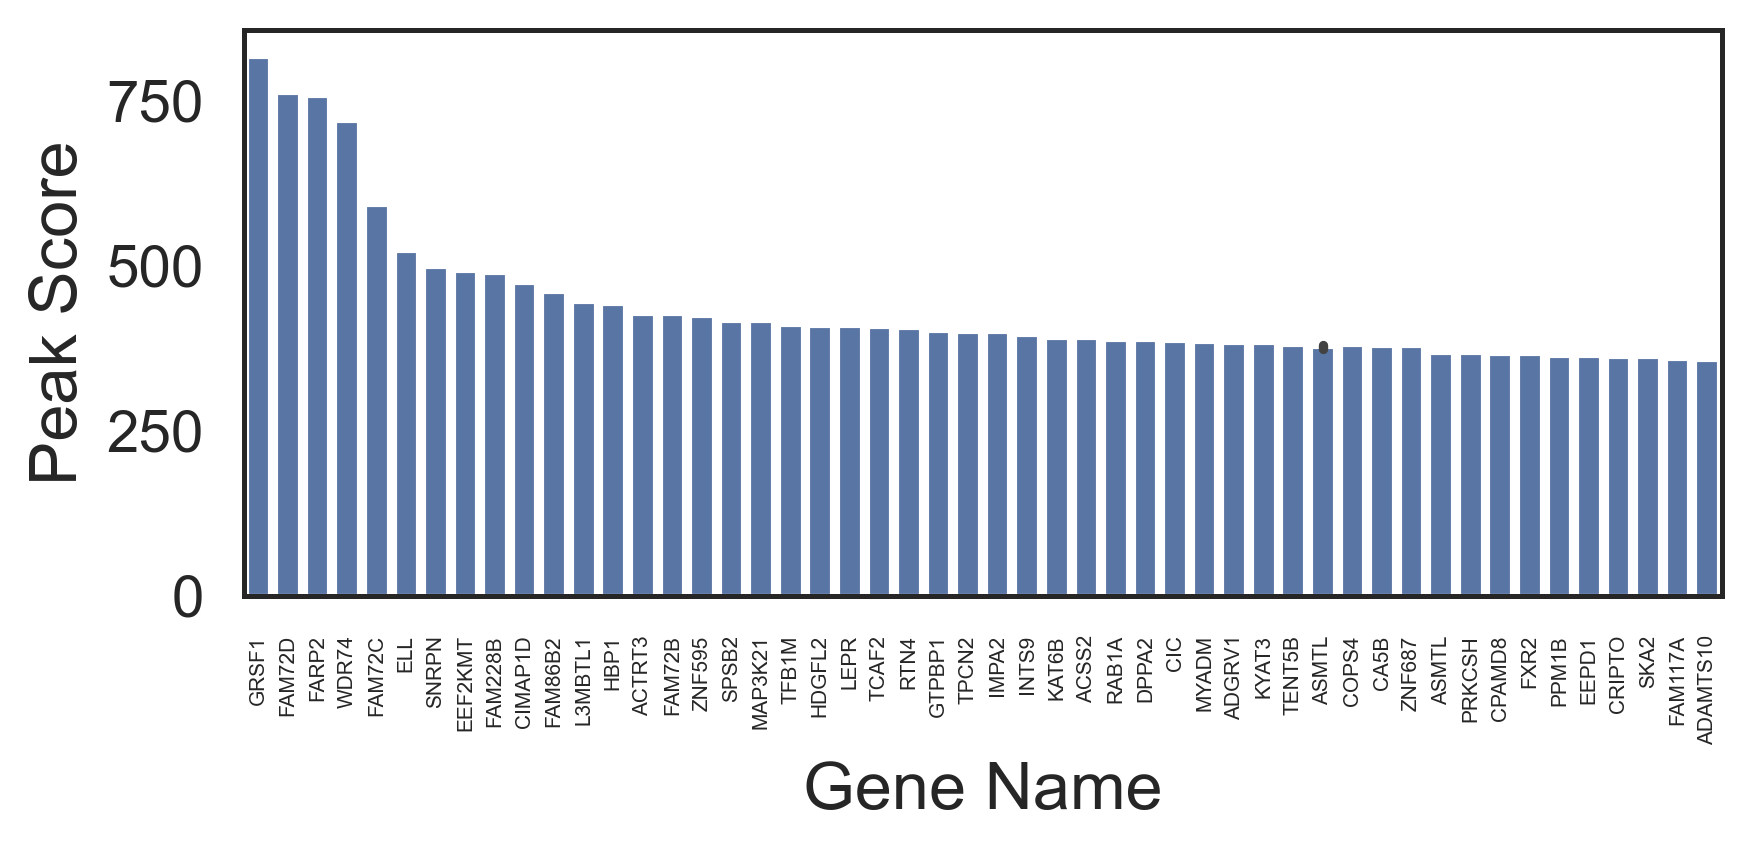

In [198]:
# ---------- Plotting Parameters ----------
sns.set_theme(style="white")  # Clean, publication-friendly
plt.rcParams.update({
    'font.family': 'Arial',
    'axes.linewidth': 1.2,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi': 300
})

# ---------- Plotting ----------
fig, ax = plt.subplots(figsize=(6, 3))  # Adjust size for figure panel

# Basic bar plot
sns.barplot(
    data=df_annotation[0:51],
    x='Gene Name',
    y='Peak Score',
    #palette='Set1',
    ax=ax
)

# ---------- Aesthetics ----------
#ax.set_xlabel("Condition", labelpad=10)
#ax.set_ylabel("Relative Expression (a.u.)", labelpad=10)
ax.set_xticklabels(labels=df_annotation[0:51]['Gene Name'], rotation = 90, size = 5)
#ax.set_title("Expression of Target Gene", pad=15, weight='bold')

# Remove unnecessary borders
#sns.despine(trim=True)

# Optionally add statistical significance markers
# Example (manual):
# ax.text(0.5, 1.2, '*', ha='center', va='bottom', fontsize=20)

# ---------- Save Figure ----------
plt.tight_layout()
plt.savefig("figures/fig7D peak_score.pdf", dpi=600, bbox_inches='tight')
plt.show()

C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\1347196724.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\huangq\AppData\Local\Temp\ipykernel_35528\1347196724.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels=df_annotation_gtf[0:50]['Gene Name'], rotation = 90, size = 5)


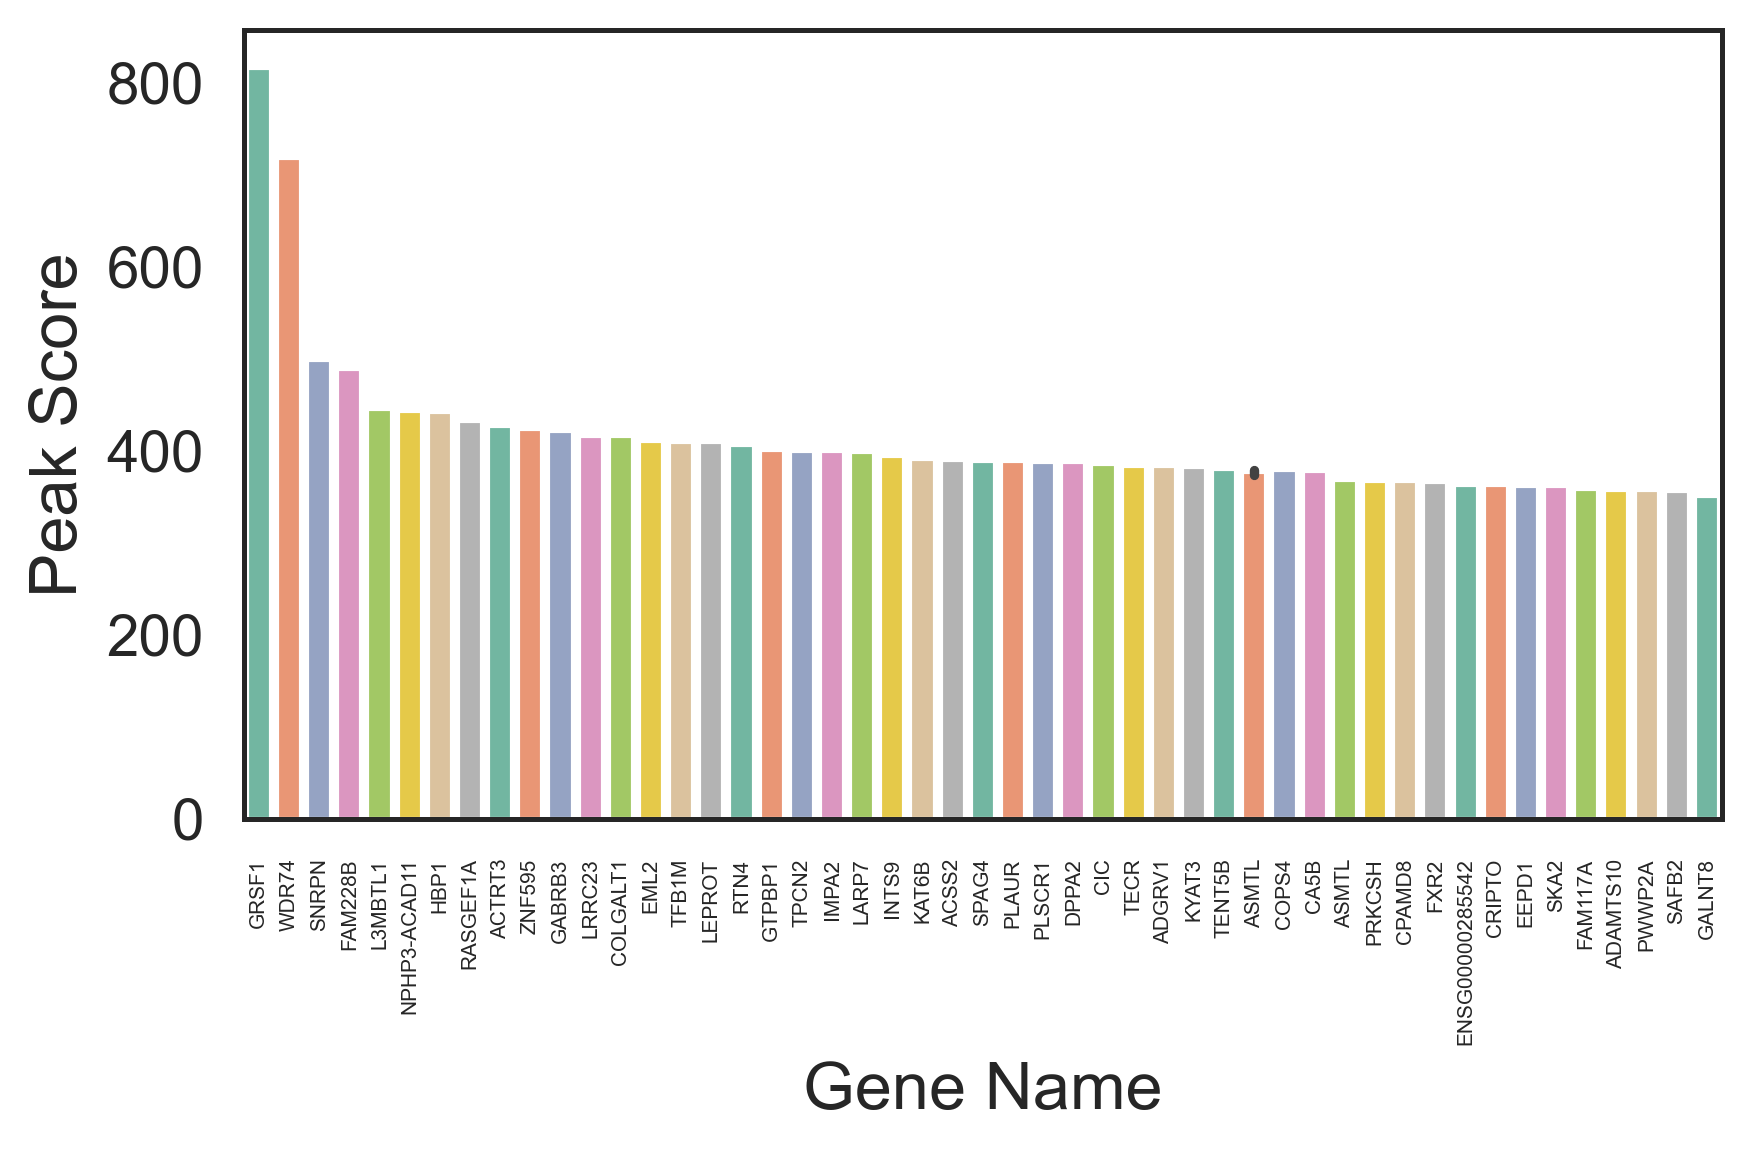

In [164]:
# ---------- Plotting Parameters ----------
sns.set_theme(style="white")  # Clean, publication-friendly
plt.rcParams.update({
    'font.family': 'Arial',
    'axes.linewidth': 1.2,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi': 300
})

# ---------- Plotting ----------
fig, ax = plt.subplots(figsize=(6, 4))  # Adjust size for figure panel

# Basic bar plot
sns.barplot(
    data=df_annotation_gtf[0:50],
    x='Gene Name',
    y='Peak Score',
    palette='Set2',
    ax=ax
)

# ---------- Aesthetics ----------
#ax.set_xlabel("Condition", labelpad=10)
#ax.set_ylabel("Relative Expression (a.u.)", labelpad=10)
ax.set_xticklabels(labels=df_annotation_gtf[0:50]['Gene Name'], rotation = 90, size = 5)
#ax.set_title("Expression of Target Gene", pad=15, weight='bold')

# Remove unnecessary borders
#sns.despine(trim=True)

# Optionally add statistical significance markers
# Example (manual):
# ax.text(0.5, 1.2, '*', ha='center', va='bottom', fontsize=20)

# ---------- Save Figure ----------
plt.tight_layout()
#plt.savefig("barplot_publication.png", dpi=600, bbox_inches='tight')
plt.show()

In [179]:
df_annotation_gtf_intersect = df_annotation_gtf[0:50][df_annotation_gtf[0:50]['Gene Name'].isin(df_annotation[0:50]['Gene Name'].tolist())]
df_annotation_gtf_only = df_annotation_gtf[0:50][~df_annotation_gtf[0:50]['Gene Name'].isin(df_annotation[0:50]['Gene Name'].tolist())]
df_annotation_default_only = df_annotation[0:50][~df_annotation[0:50]['Gene Name'].isin(df_annotation_gtf[0:50]['Gene Name'].tolist())]

In [185]:

for i in df_annotation[0:100]['Gene Name'].tolist():
    print(i)

GRSF1
FAM72D
FARP2
WDR74
FAM72C
ELL
SNRPN
EEF2KMT
FAM228B
CIMAP1D
FAM86B2
L3MBTL1
HBP1
ACTRT3
FAM72B
ZNF595
SPSB2
MAP3K21
TFB1M
HDGFL2
LEPR
TCAF2
RTN4
GTPBP1
TPCN2
IMPA2
INTS9
KAT6B
ACSS2
RAB1A
DPPA2
CIC
MYADM
ADGRV1
KYAT3
TENT5B
ASMTL
COPS4
CA5B
ZNF687
ASMTL
PRKCSH
CPAMD8
FXR2
PPM1B
EEPD1
CRIPTO
SKA2
FAM117A
ADAMTS10
PWWP2A
PPM1B
GALNT8
AP2A1
DET1
HSPD1
VMAC
TMEM18
PRR12
MYL11
FOXN2
CRYZL1
ETV5
HMGB2
VCPIP1
PITRM1
HNRNPL
ZNF331
LRIF1
REST
ZBTB20
AGBL5
ARL17A
FRYL
NPRL3
HNRNPD
PCBP3
GGPS1
KCNC3
TMEM87B
DCLK1
BABAM1
PARK7
DNM1L
KAT6B
RSU1
JUN
TOX4
TCF7L2
CEP120
JPT1
RAB6A
SWT1
ZNF558
RRBP1
PJA2
DCP2
HS3ST3B1
YPEL5
RAB5B


In [200]:
df_annotation[df_annotation['Gene Name'] == 'SALL2']

,Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
PeakID,,,,,,,,,,,,,,,,,,
n47_qval0.01_peak_7754,chr14,21995113,21995630,+,189.5,NaN,promoter-TSS (NR_111967),promoter-TSS (NR_111967),-891.0,NM_001364564,6297.0,NaN,NM_005407,ENSG00000165821,SALL2,COLB|HSAL2|Sal-2|ZNF795|p150(Sal2),spalt like transcription factor 2,protein-coding
n47_qval0.01_peak_7753,chr14,21994330,21994813,+,180.5,NaN,promoter-TSS (NR_111967),promoter-TSS (NR_111967),-91.0,NM_001364564,6297.0,NaN,NM_005407,ENSG00000165821,SALL2,COLB|HSAL2|Sal-2|ZNF795|p150(Sal2),spalt like transcription factor 2,protein-coding
